## Exploration and comparison of tasseled cap components generated from different coefficients

This notebook compares Tasseled cap wetness, greeness and brightness (TCW, TCG and TCB) derived from different sets of coefficients to see if there are significant differences in the output data. 

### Why do this work?

We currently use a single set of coefficients for generating TCW, TCG and TCB across all of the Landsat sensors (5, 7, 8 and 9). We use the coefficients of [Crist (1985)](https://www.sciencedirect.com/science/article/abs/pii/0034425785901026?via%3Dihub) to calculate the TC components from the DEA Landsat surface reflectance data ([see here](https://link.springer.com/content/pdf/10.1007/s13157-023-01682-7.pdf) for explanation of how TCW is generated to be used in WIT).

However, there are sensor-specific coefficients published and widely used for each Landsat sensor, and the use of a single set of coefficients to generate TC's for all sensors may introduce errors into our final products. A comparison between the TC's being created using the currently implemented coefficients, and those recommended in the wider literature, should be done to determine if our TC product needs to be updated to include sensor-specific coefficients.

### What this notebook does

- Loads DEA Landsat ARD data
- Uses `dea_tools` `calculate_indices` to calculate TCW, TCG and TCB using the currently implemented coefficients, and also the Landsat 8/9 coefficients from [Baig et al. 2014](https://www.tandfonline.com/doi/citedby/10.1080/2150704X.2014.915434?scroll=top&needAccess=true)
- `dea_tools` `bandindices.py` has been modified to include versions of the TC equations using the Landsat 8 coefficients.
- Calculates the difference between each TC component generated using the two sets of coefficients
- Generates figures to illustrate the differences between the TC outputs of the differenc coefficients
- calculates the Pearsons' r for the pairs of coefficients
- Calculate the RMSE, MAE and bias between the coefficients for each TC

### Still in progress:
- import wofs and generate other spectral indicies and use this extra information to see if there are larger discrepencies between the TC coefficients for particular land covers
- scale up the area of analysis to one (or all) of the golden tiles that are also used for testing the GeoMedian. Currently the notebook runs for a small area in Victoria, so the results should be seen as preliminary and for assessing the notebook itself, not the TC's.
- Once the notebook is ready to run over a larger sample area, also add hypothesis testing to determine if the differences are actually statistically different (use P > 0.05 or p > 0.01 depending on how strict we want to be)
- Investigate the broader literature on what degree of pre-rpocessing is ususally applied to the input data. Our ARD data has several quality checks/ processes applied to it. If it is different enough from what is published, and it would have a significant impact on the resulting coefficients, there would be an argument for DEA to generate our own coefficients that are tailored to our ARD data (To discuss with Bex)



In [1]:
%pip install ultraplot xskillscore -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import datacube
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import ultraplot as uplt
import xskillscore
from matplotlib.dates import MonthLocator
from datacube.drivers.netcdf import write_dataset_to_netcdf
from datacube.utils import masking
from scipy.stats import pearsonr, linregress
import calendar

import sys
sys.path.insert(1, '.../Tools')
from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb, display_map
from dea_tools.dask import create_local_dask_cluster
from dea_tools.bandindices import calculate_indices

In [3]:
create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 3,Total memory: 28.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34081,Workers: 1
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,Total threads: 3
Started: Just now,Total memory: 28.21 GiB
Comm: tcp://127.0.0.1:37653,Total threads: 3
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/41645/status,Memory: 28.21 GiB
Nanny: tcp://127.0.0.1:34945,


In [4]:
dc = datacube.Datacube(app="TCP_initial_exploration")

In [5]:
# calculate statistics over the individual TC scenes
def reduce(ds):
    yy = xr_quantile_bands(ds, [0.1, 0.5, 0.9], nodata=np.nan)
    return yy

In [6]:
lat = -35.5200
lon = 144.0000
buffer = 0.05

lat_range = (lat - buffer, lat + buffer)
lon_range = (lon - buffer, lon + buffer)

resolution = (-30, 30)
measurements = ["nbart_blue", "nbart_green", "nbart_red", "nbart_nir", "nbart_swir_1", "nbart_swir_2", "oa_fmask", "oa_nbart_contiguity"]
dask_chunks = dict(time=10, x=512, y=512)

In [7]:
#display_map(x=lon_range, y=lat_range)

In [8]:
# set up baseline dc query. THis will be modified by functions as needed later on.
query = {
    'x': lon_range,
    'y': lat_range,
    'time': ('2024-01', '2024-12'),
    'measurements': measurements,
    'resolution': resolution,
    'group_by': 'solar_day',
    'output_crs': 'EPSG:3577'
}

### Load the Landsat ARD data 

We will use this to generate the TC's, rather than use the existing TC product. This way we know the same pre-processing has been applied to both sets of coefficients.

In [9]:
ds = load_ard(
    dc=dc,
    products=['ga_ls8c_ard_3', 'ga_ls9c_ard_3'],
    cloud_mask = 'fmask',
    mask_pixel_quality=True,
    mask_contiguity = True,
    **query
)

Finding datasets
    ga_ls8c_ard_3
    ga_ls9c_ard_3
Applying fmask pixel quality/cloud mask
Applying contiguity mask (oa_nbart_contiguity)
Loading 91 time steps


/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


In [10]:
print(f"time range: {pd.to_datetime(ds.time.min().values).strftime('%Y-%b-%d')} to {pd.to_datetime(ds.time.max().values).strftime('%Y-%b-%d')}")
#ds

time range: 2024-Jan-01 to 2024-Dec-26


### Generate masks for grouping data by broad land types

Using wofs and fractional cover, create mask arrays that will be applied to the TC's generated from the coefficients. 

This is to try and see if, in the result that there are differences between the TC coefficients, if those differences are related to particular land covers or conditions.

In [11]:
wofs_measurements= ['frequency']
wofs_mask = 0.4 # set the threshold for classifying 'wet' pixels

wofs_query = query

wofs_query.update({
    'measurements':wofs_measurements
})

ds_wofs = dc.load(
    product='ga_ls_wo_fq_cyear_3',
    **query
)

ds_wof = masking. mask_invalid_data(ds_wofs)
ds_wofs['wet_pixels'] = (ds_wofs['frequency'] > wofs_mask).astype(int)

In [12]:
"""
Set the threshold for classifying 'green' and 'other' pixels.

NOTE: this is a VERY rough proxy and should be replaced with a better set of thresholds to get actual groups of bare soil, 
consistently vegetated areas (e.g native vegetation or forests) and dynamic agricultural regions.
"""
fc_measurements=['bs_pc_50', 'pv_pc_50', 'npv_pc_50']
fc_pv_mask = 40 

fc_query = query
fc_query.update({
    'measurements':fc_measurements
})

ds_fc = dc.load(
    product='ga_ls_fc_pc_cyear_3',
    **query
)

ds_fc = masking.mask_invalid_data(ds_fc)

ds_fc_wofs_masked = ds_fc.where(~ds_wofs['wet_pixels'])

ds_fc_wofs_masked['green'] = ((ds_fc_wofs_masked['pv_pc_50'] > fc_pv_mask) & (ds_wofs['wet_pixels'] ==0)).astype(int)
ds_fc_wofs_masked['bare'] = ((ds_fc_wofs_masked['bs_pc_50'] > fc_pv_mask) & (ds_wofs['wet_pixels'] ==0)).astype(int)

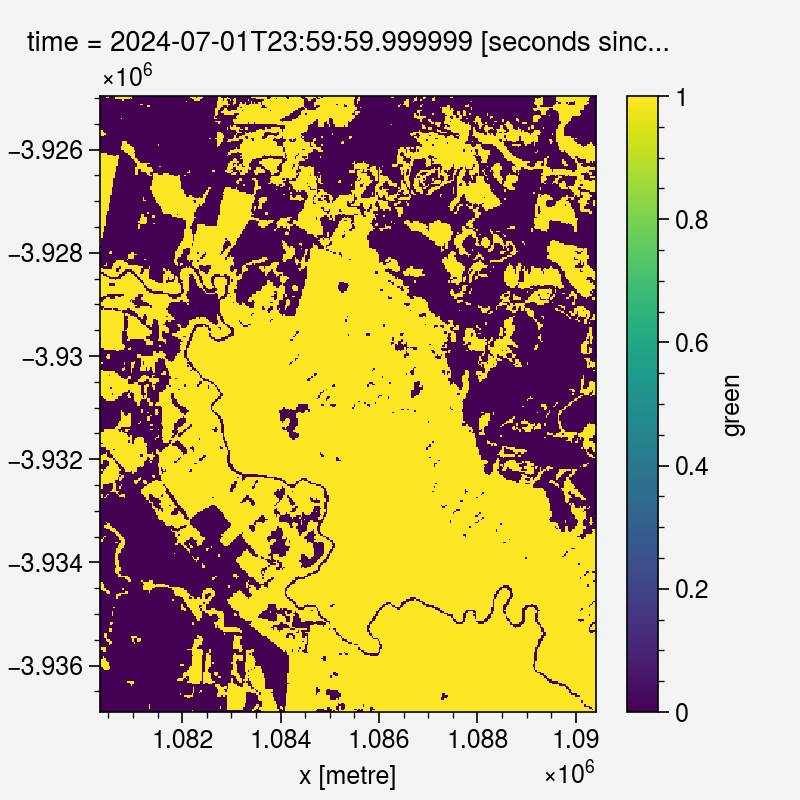

In [13]:
ds_fc_wofs_masked['green'].plot()

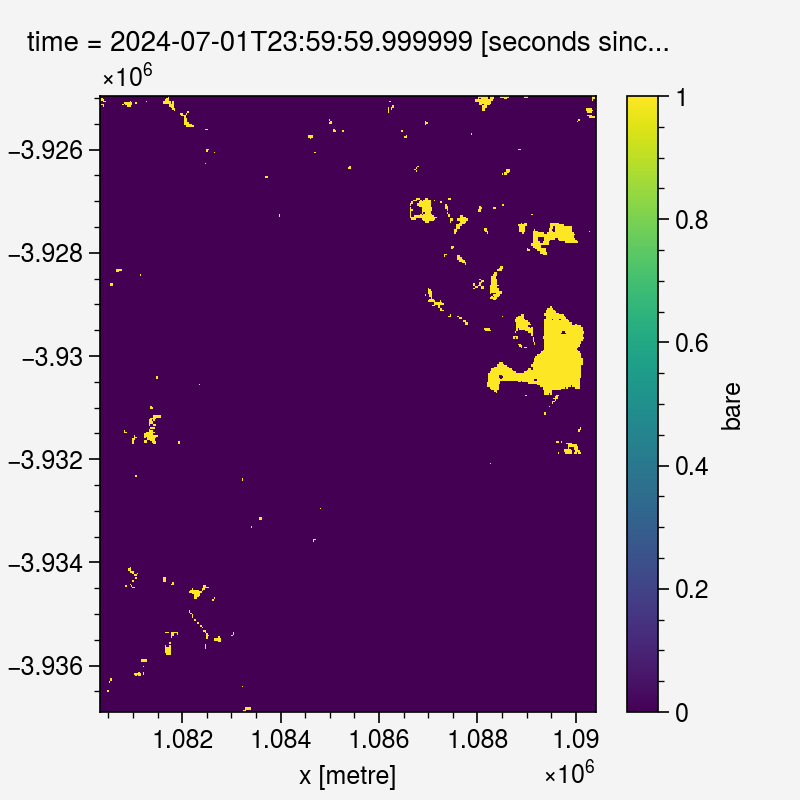

In [14]:
ds_fc_wofs_masked['bare'].plot()

In [15]:
"""
NOTE: for now, before running the index calculations, you need to go to the '...Tools' directory and run pip install to access local changes.

The bandindices.py file has had additional TC equations added to it in the branch. These are not part of the standard dea_tools package.

pip install -e .

"""
ds_tc = calculate_indices(ds, 
                          index=['NDVI','TCW', 'TCB', 'TCG', 'TCW_ls8ls9', 'TCB_ls8ls9', 'TCG_ls8ls9'], 
                          drop=True,
                          inplace=True,
                          collection = 'ga_ls_3')

Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir', 'nbart_swir_1', 'nbart_swir_2', 'oa_fmask', 'oa_nbart_contiguity']


In [16]:
# find difference between the two versions of the TC
ds_tc['TCW_diff'] = ds_tc['TCW'] - ds_tc['TCW_ls8ls9']
ds_tc['TCG_diff'] = ds_tc['TCG'] - ds_tc['TCG_ls8ls9']
ds_tc['TCB_diff'] = ds_tc['TCB'] - ds_tc['TCB_ls8ls9']

In [17]:
"""
The masks created earlier have a single timestep as they are created from annual products. 
They are broadcast across all of the timesteps for the xarray Dataset containing the TC's
"""

ds_tc['wofs_wet_pixels'] =ds_wofs['wet_pixels'].isel(time=0).expand_dims(time=ds_tc.time)
ds_tc['bare'] =ds_fc_wofs_masked['bare'].isel(time=0).expand_dims(time=ds_tc.time)
ds_tc['green'] =ds_fc_wofs_masked['green'].isel(time=0).expand_dims(time=ds_tc.time)

ds_tc

<xarray.Dataset> Size: 779MB
Dimensions:          (time: 91, y: 398, x: 336)
Coordinates:
  * time             (time) datetime64[ns] 728B 2024-01-01T00:09:22.123303 .....
  * y                (y) float64 3kB -3.925e+06 -3.925e+06 ... -3.937e+06
  * x                (x) float64 3kB 1.08e+06 1.08e+06 ... 1.09e+06 1.09e+06
    spatial_ref      int32 4B 3577
Data variables: (12/13)
    NDVI             (time, y, x) float32 49MB 0.3121 0.3539 ... 0.251 0.09261
    TCW              (time, y, x) float32 49MB -0.2619 -0.2562 ... 0.003667
    TCB              (time, y, x) float32 49MB 0.3231 0.3168 ... 0.09733 0.08216
    TCG              (time, y, x) float32 49MB 0.05477 0.0639 ... 0.002717
    TCW_ls8ls9       (time, y, x) float32 49MB -0.1752 -0.1713 ... 0.01787
    TCB_ls8ls9       (time, y, x) float32 49MB 0.4685 0.4578 ... 0.1007 0.08578
    ...               ...
    TCW_diff         (time, y, x) float32 49MB -0.0867 -0.0849 ... -0.01421
    TCG_diff         (time, y, x) float32 49MB 0.01143 0.01097 ... 0.005488
    TCB_diff         (time, y, x) float32 49MB -0.1453 -0.141 ... -0.003615
    wofs_wet_pixels  (time, y, x) int64 97MB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 1
    bare             (time, y, x) int64 97MB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    green            (time, y, x) int64 97MB 0 0 0 0 1 1 0 0 ... 1 1 1 1 1 1 1 0
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [18]:
"""
This cell is currently not being used, but if you need to sub-sample the xarray Dataset to speed up the notebook, you can use the commented code here.
"""

ds_tc_sub = ds_tc
#ds_tc_sub = ds_tc.isel(time=slice(None, None, 5),x=slice(None, None, 5), y=slice(None, None, 5)) #sub-sampling to speed up graph generation
#ds_tc_sub

### Plot the differences between the TC's generated from the two sets of coefficients

- Histogram of differences between coefficients (flatten the timesteps to just see all datapoints)
- hexbin facet plots to see correlation between the TC coefficient pairs

In [19]:
%%time
ds_diff = np.stack([ds_tc_sub['TCW_diff'].values.flatten(), ds_tc_sub['TCG_diff'].values.flatten(), ds_tc_sub['TCB_diff'].values.flatten()], axis=1)
ds_diff.shape

CPU times: user 60.6 ms, sys: 64.5 ms, total: 125 ms
Wall time: 122 ms


(12169248, 3)

CPU times: user 618 ms, sys: 109 ms, total: 727 ms
Wall time: 703 ms


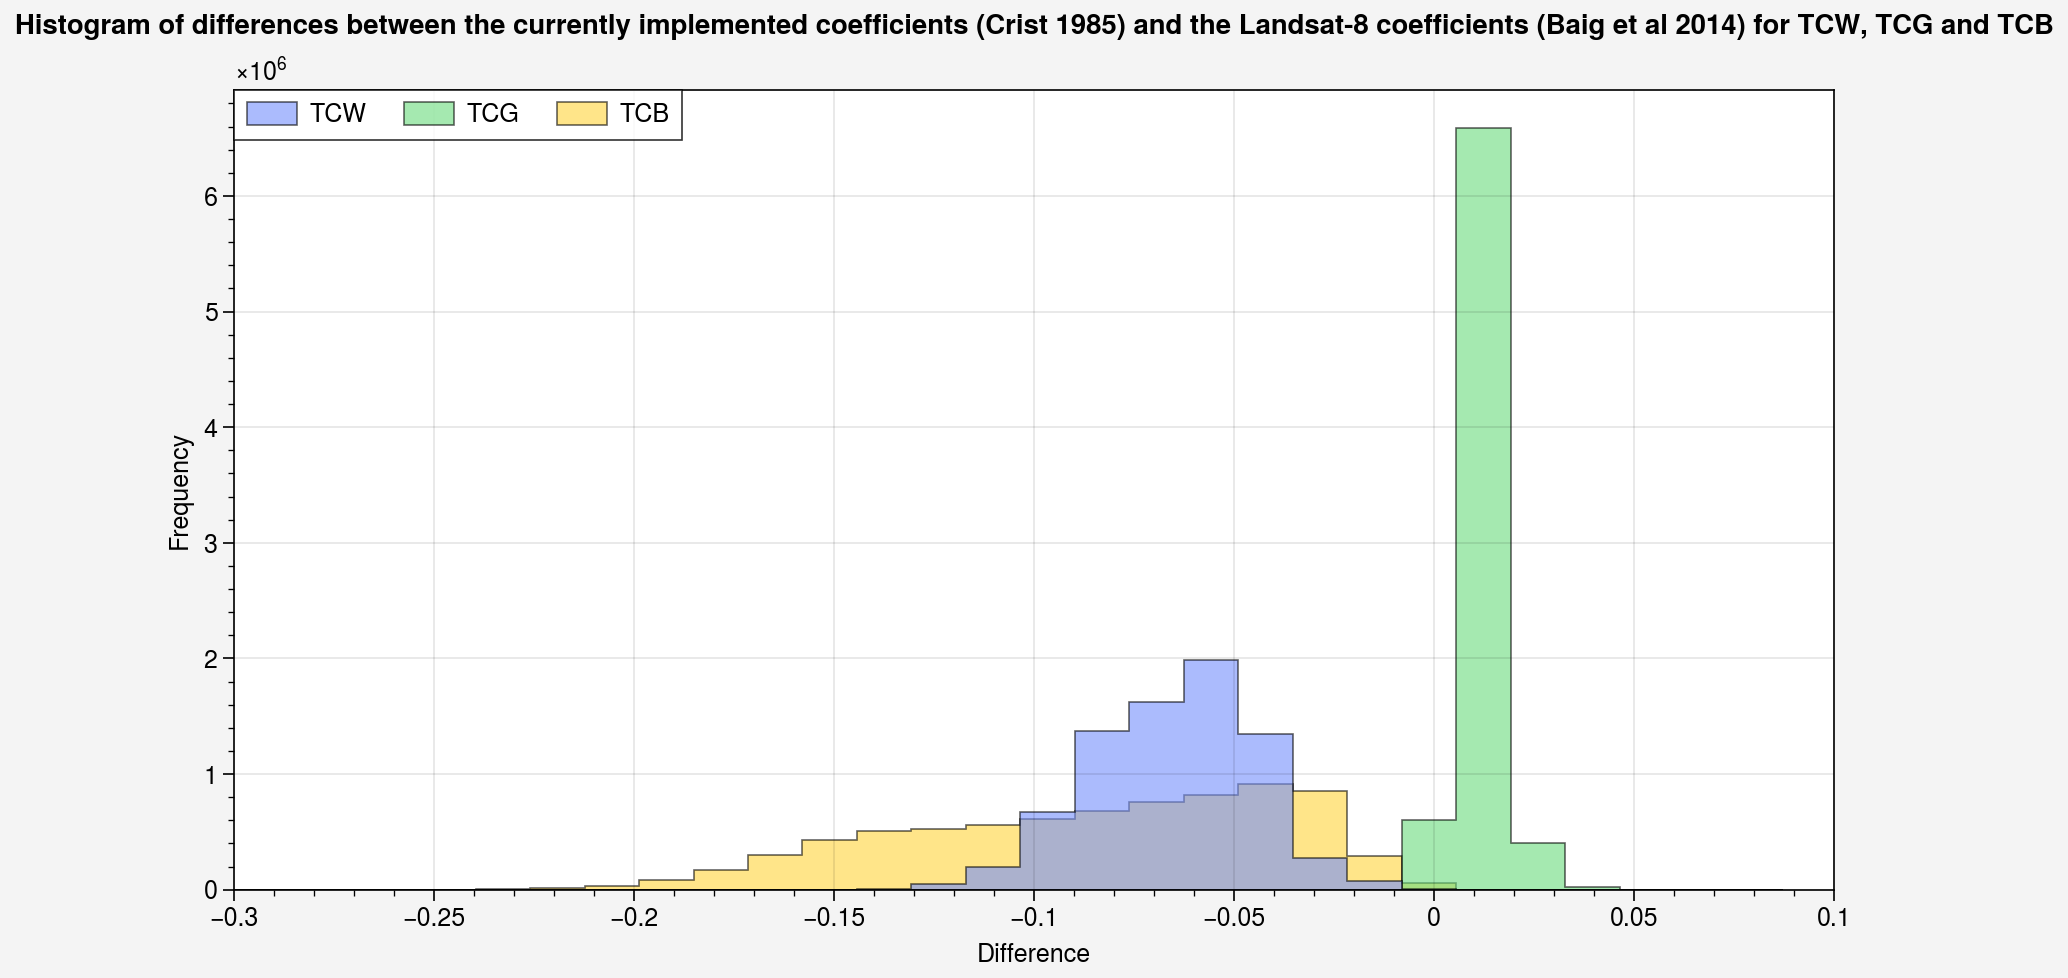

In [20]:
%%time
# plot histogram subplots for the 3 TC's

fig, ax = uplt.subplots(refwidth=8, refaspect=(8,4))
ax.format(suptitle='Histogram of differences between the currently implemented coefficients (Crist 1985) and the Landsat-8 coefficients (Baig et al 2014) for TCW, TCG and TCB', xlabel='Difference', ylabel='Frequency')
res = ax.hist(
    ds_diff,
    bins=50,
    histtype='stepfilled',
    filled=True,
    alpha=0.6,
    edgecolor='k',
    cycle=('indigo4', 'green4', 'yellow4'),
    labels=list(['TCW', 'TCG', 'TCB']),
    legend='ul'
    
)
ax.format(xlim=(-0.3, 0.1))

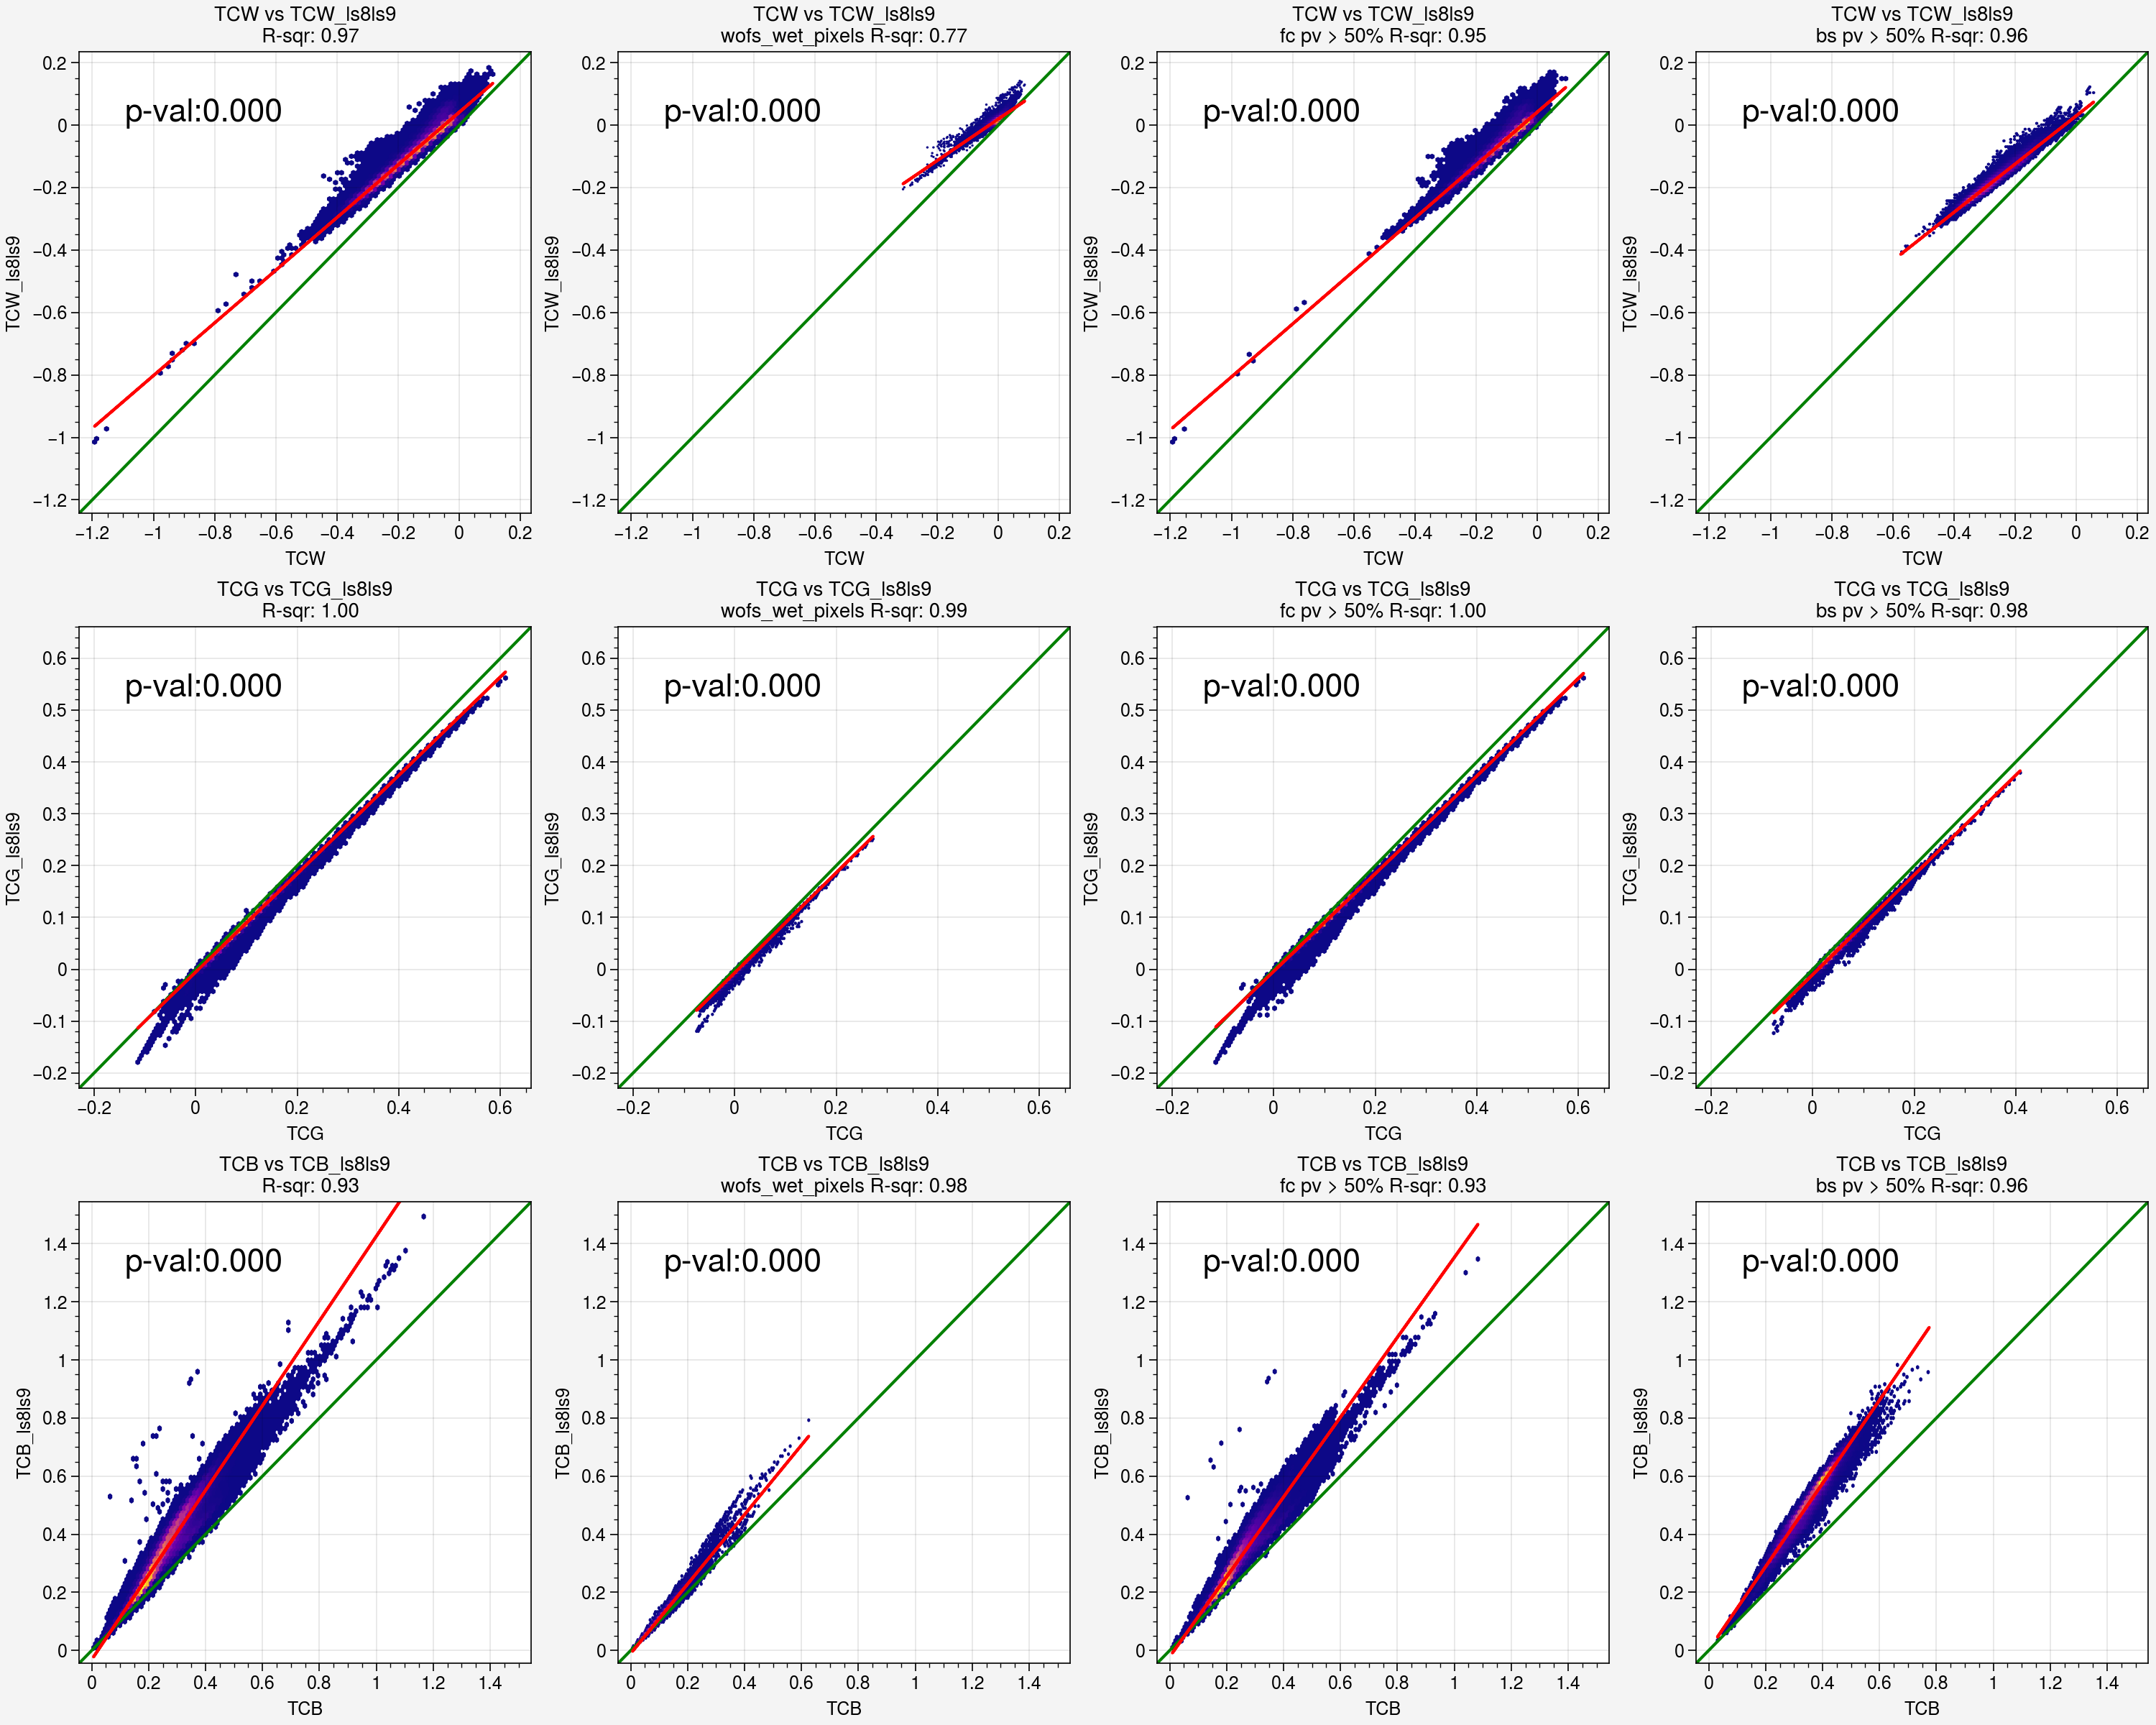

In [31]:
variable_pairs = [
    ('TCW', 'TCW_ls8ls9'),
    ('TCG', 'TCG_ls8ls9'),
    ('TCB', 'TCB_ls8ls9')
]

all_values = xr.DataArray(
    data = np.ones_like(ds_tc_sub['wofs_wet_pixels'], dtype=bool),
    coords = ds_tc_sub['wofs_wet_pixels'].coords,
    dims = ds_tc_sub['wofs_wet_pixels'].dims)

class_masks = {
    ' ': all_values,
    'wofs_wet_pixels': ds_tc_sub['wofs_wet_pixels'],
    'fc pv > 50%': ds_tc_sub['green'],
    'bs pv > 50%': ds_tc_sub['bare']
}


colors = ('indigo4', 'green4', 'yellow4')

fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(15, 12), layout='constrained')


for i, ((var1, var2), color) in enumerate(zip(variable_pairs, colors)):
    ax=axs[i]

    data1 = ds_tc_sub[var1].values.ravel()
    data2 = ds_tc_sub[var2].values.ravel()

    # remove nans for correlation and plotting
    mask = ~np.isnan(data1) & ~np.isnan(data2)
    data1_clean = data1[mask]
    data2_clean = data2[mask]
    lower_limit = np.min((data1_clean.min(), data2_clean.min())) - 0.05
    upper_limit = np.max((data1_clean.max(), data2_clean.max())) + 0.05

    for j, (class_name, class_mask) in enumerate(class_masks.items()):
        ax = axs[i,j]
        class_values = class_mask.values.ravel()[mask]

        hb = ax.hexbin(
            data1_clean[class_values==1],
            data2_clean[class_values==1],
            gridsize=100,
            cmap='plasma',
            mincnt=1
        )
        ax.set_xlim(lower_limit, upper_limit)
        ax.set_ylim(lower_limit, upper_limit)
        ax.plot((lower_limit, upper_limit), (lower_limit, upper_limit), c='g')
        
        if np.sum(class_values ==1) >1:
            result = linregress(data1_clean[class_values==1], data2_clean[class_values==1])
        else:
            result = np.nan
        ax.plot(data1_clean[class_values==1], result.intercept + result.slope*data1_clean[class_values==1], 'r', label='fit line')
        ax.text(0.1, 0.9, f'p-val:{result.pvalue:.3f}', fontsize=16, ha='left', va='top', transform=ax.transAxes)

    # annotate
        ax.set_title(f'{var1} vs {var2}\n{class_name} R-sqr: {result.rvalue**2:.2f}')
        ax.set_xlabel(var1)
        ax.set_ylabel(var2)

plt.show()

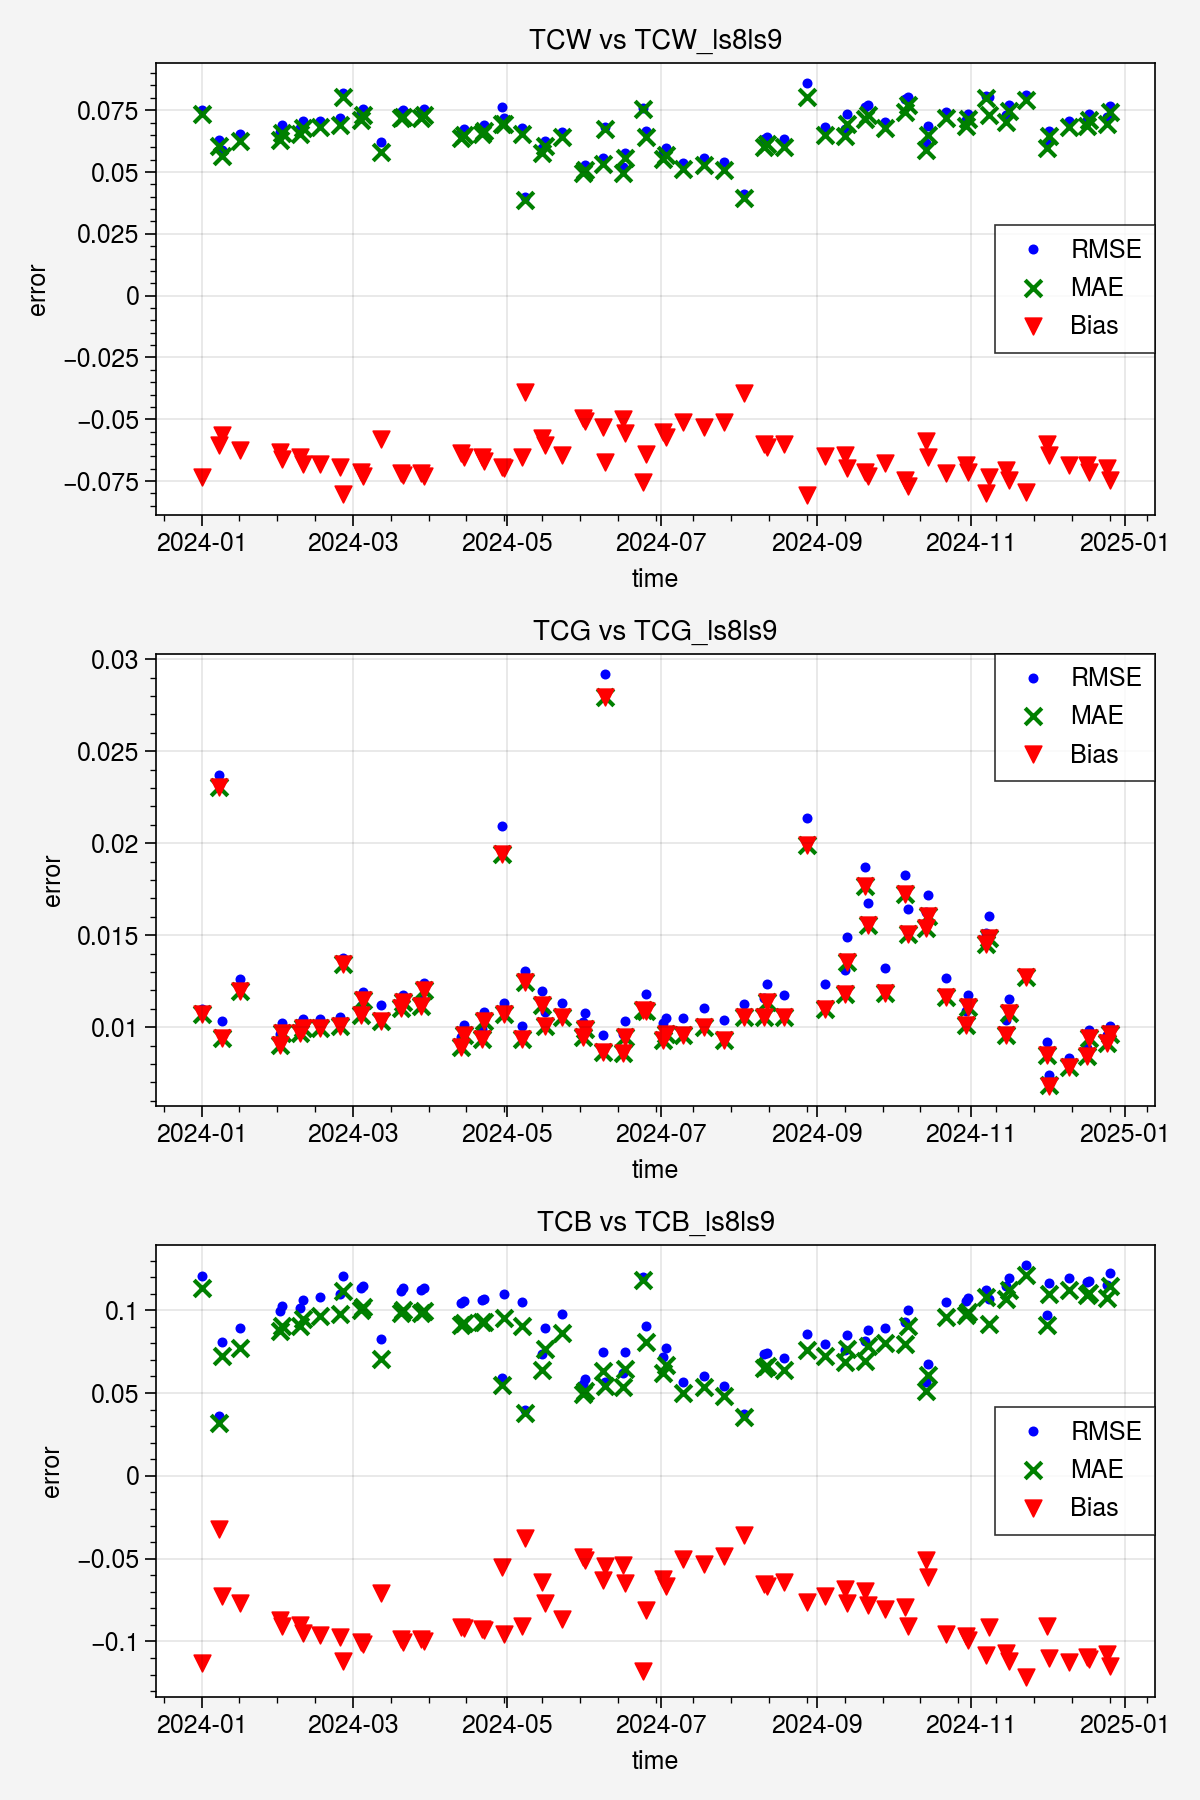

In [22]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6,9))

for i, (var1, var2) in enumerate(variable_pairs):
    ax=axs[i]
    diff = ds_tc_sub[var1] - ds_tc_sub[var2]
    rmse = np.sqrt((diff ** 2).mean(dim=['x', 'y']))
    mae = np.abs(diff).mean(dim=['x', 'y'])
    bias = diff.mean(dim=['x', 'y'])
    #plot the metrics
    ax.scatter(ds_tc_sub['time'], rmse, label='RMSE', c='blue', marker='.')
    ax.scatter(ds_tc_sub['time'], mae, label='MAE', c='green', marker='x')
    ax.scatter(ds_tc_sub['time'], bias, label='Bias', c='red', marker='v')
    ax.set_title(f'{var1} vs {var2}')
    ax.set_xlabel('time')
    ax.set_ylabel('error')
    ax.legend()

plt.tight_layout()
plt.show()

In [23]:
ds_tc_sub['time'] = pd.to_datetime(ds_tc_sub['time'].values)
monthly_groups = ds_tc_sub.groupby('time.month')

# for month, group in monthly_groups:
#     print(f'month: {month}')
#     print(group)
#     print('\n')

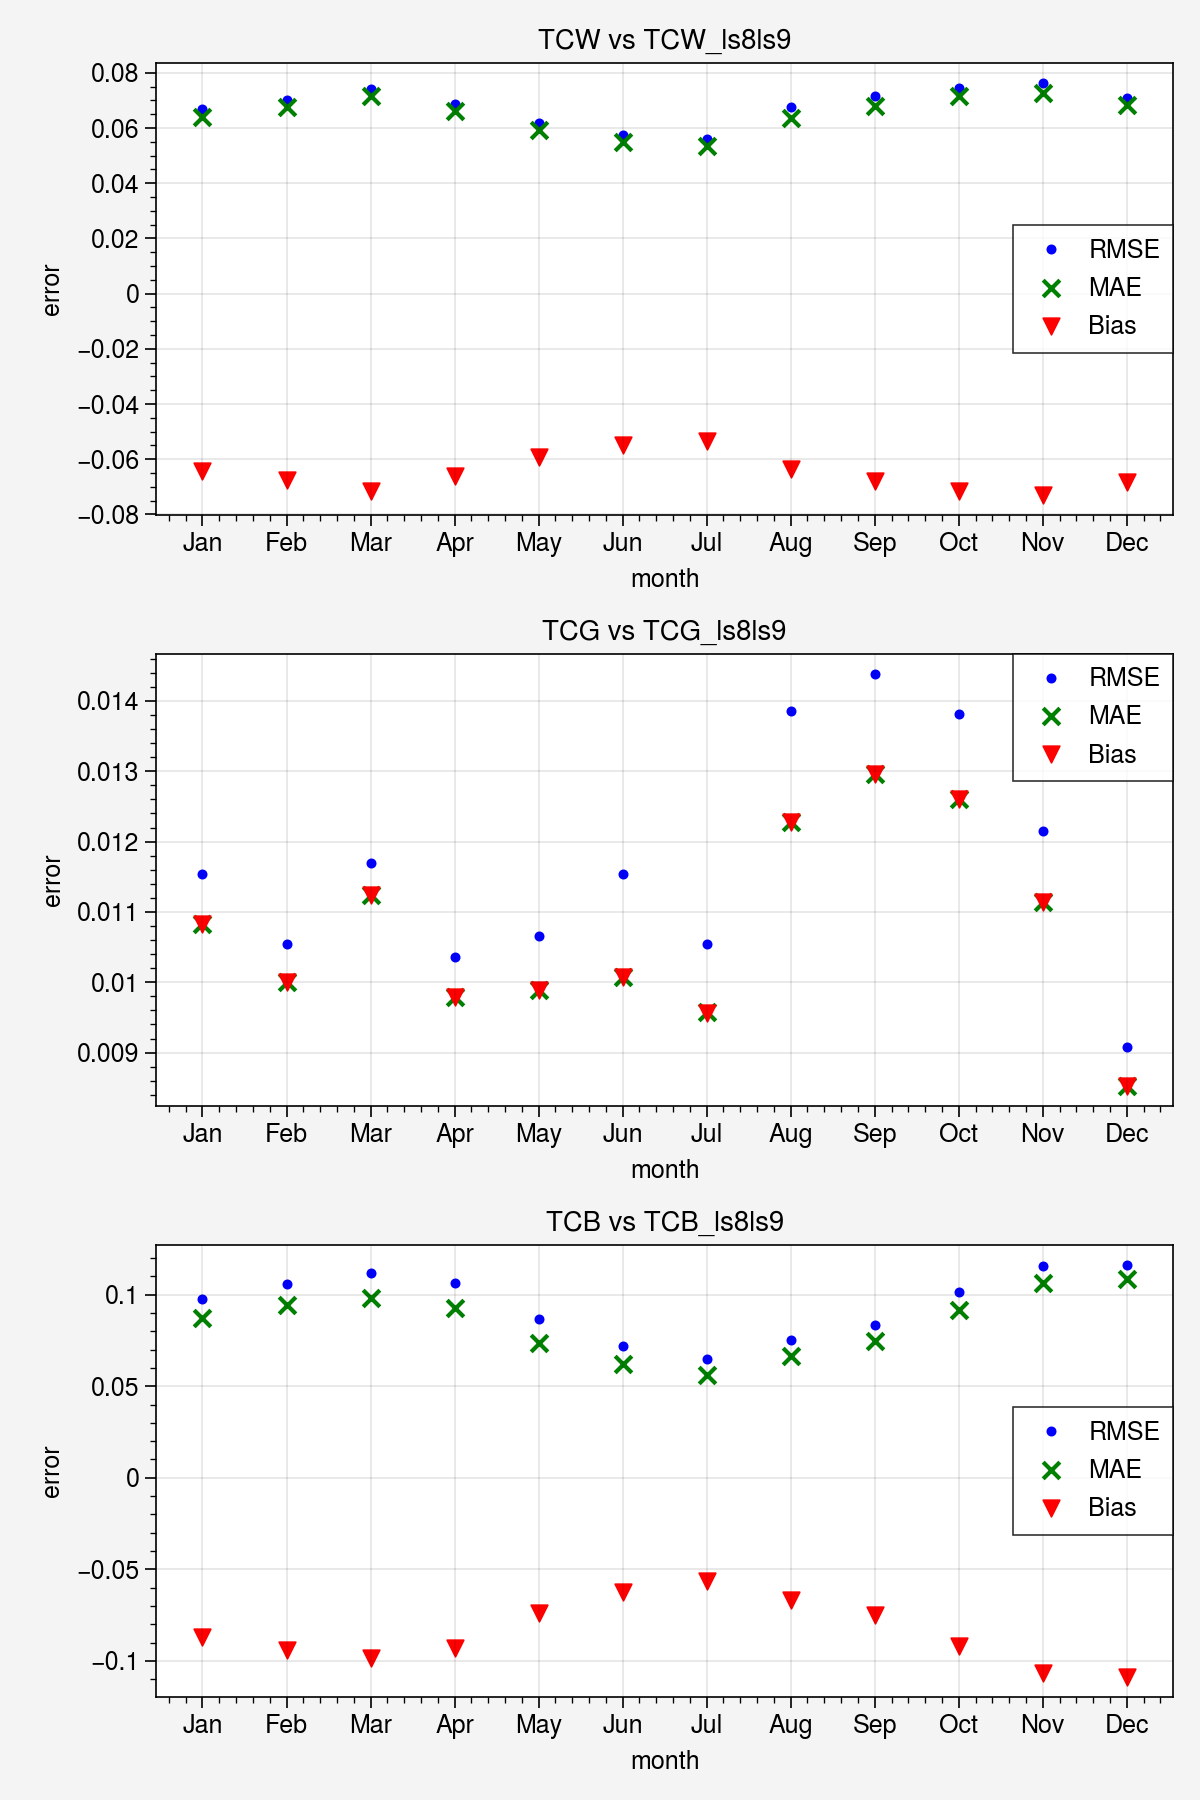

In [24]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6,9))


for i, (var1, var2) in enumerate(variable_pairs):
    ax=axs[i]
    
    months = []
    rmse_values = []
    mae_values = []
    bias_values = []

    for month, group in monthly_groups:
        months.append(month)
        
        diff = group[var1] - group[var2]
        rmse = np.sqrt((diff ** 2).mean(dim=['x', 'y', 'time'])).item()
        mae = np.abs(diff).mean(dim=['x', 'y', 'time']).item()
        bias = diff.mean(dim=['x', 'y', 'time']).item()
        
        rmse_values.append(rmse)
        mae_values.append(mae)
        bias_values.append(bias)

    ax.scatter(months, rmse_values, label='RMSE', c='blue', marker='.')
    ax.scatter(months, mae_values, label='MAE', c='green', marker='x')
    ax.scatter(months, bias_values, label='Bias', c='red', marker='v')
    ax.set_title(f'{var1} vs {var2}')
    ax.set_xlabel('month')
    ax.set_ylabel('error')
    ax.set_xticks(range(1,13))
    ax.set_xticklabels([calendar.month_name[i][:3] for i in range(1, 13)])
    ax.legend()

plt.tight_layout()
plt.show()
        

In [25]:
#diff_month = difference.groupby('time.month').median('time')

#diff_month.plot(col='month', col_wrap=3, robust=True)

In [26]:
# use SMAD to find ag areas and classify as ag pixels
# use SMAD to classify native veg pixels